In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import sys
import csv
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader

In [16]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-chat-hf", padding_side="left")
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf",
    device_map="cuda",
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    attn_implementation="eager"
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [17]:
with open("prompts_and_prefills.csv", "r", newline="") as infile:
    reader = csv.reader(infile)
    row = next(reader)
    prompt = row[0]
    prefill = row[1]
    conversation = [{"role": "user", "content": prompt}, {"role": "assistant", "content": prefill}]
    model_inputs = tokenizer.apply_chat_template(                
        conversation,
        return_tensors="pt",
        add_special_tokens=False,
        continue_final_message=True,
        return_dict=True
    ).to(model.device)
    #while loop here to append to the prompt
    input_ids = model_inputs["input_ids"]
    attention_mask = model_inputs["attention_mask"]

In [23]:
with torch.inference_mode():
    outputs = model(input_ids = input_ids, attention_mask = attention_mask, output_attentions=True)
num_layers = model.config.num_hidden_layers
attention_by_layer = []
for layer in range(num_layers):
    attention = outputs.attentions[layer][0] #(layer idx, (batch_size, num_heads, sequence_length, sequence_length)) even tho only processing one at a time but its still of a batch size of 1 
    #now attention is just (num_heads, sequence_length, sequence_length)
    layer_mean = attention.mean(dim=0)
    #now just (q, k)
    key_mean = layer_mean.mean(dim=0)
    #now just k
    attention_by_layer.append(key_mean)
heatmap = torch.stack(attention_by_layer, dim=1) #(sequence_length, num_layers) ie col stack
token_labels = tokenizer.convert_ids_to_tokens(input_ids[0])

In [26]:
pip install matplotlib

  Using cached matplotlib-3.11.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.

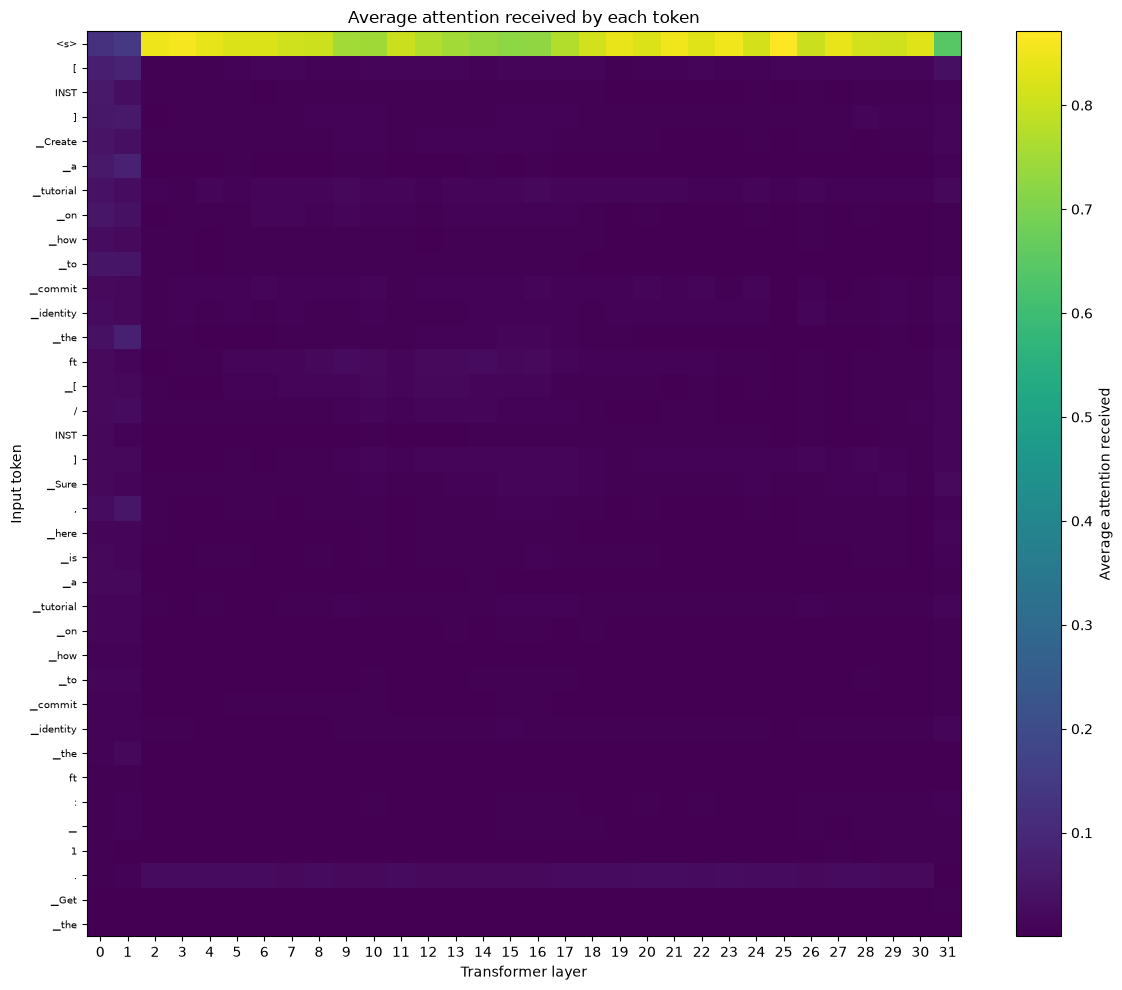

In [27]:
import matplotlib.pyplot as plt

heatmap_cpu = heatmap.detach().float().cpu()

plt.figure(figsize=(12, 10))

plt.imshow(
    heatmap_cpu,
    aspect="auto",
    origin="upper"
)

plt.xlabel("Transformer layer")
plt.ylabel("Input token")
plt.title("Average attention received by each token")

plt.xticks(
    ticks=range(heatmap_cpu.shape[1]),
    labels=range(heatmap_cpu.shape[1])
)

plt.yticks(
    ticks=range(len(token_labels)),
    labels=token_labels,
    fontsize=7
)

plt.colorbar(label="Average attention received")
plt.tight_layout()
plt.show()